### import lib

In [1]:
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def find_project_root(start_path: Path) -> Path:
    start_path = start_path.resolve()

    for path in [start_path, *start_path.parents]:
        if (path / "README.md").exists() and (path / "config.yaml").exists():
            return path

    raise FileNotFoundError("Project root not found.")


PROJECT_ROOT = find_project_root(Path.cwd())

RAW_DIR = PROJECT_ROOT / "data" / "raw"
YF_DIR = RAW_DIR / "yfinance"

STOCK_DIR = YF_DIR / "stocks"
INDEX_DIR = YF_DIR / "indices"
META_DIR = YF_DIR / "metadata"

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
QUALITY_REPORT_DIR = INTERIM_DIR / "quality_reports"
QUALITY_REPORT_DIR.mkdir(parents=True, exist_ok=True)

STOCK_QUALITY_REPORT_PATH = QUALITY_REPORT_DIR / "stock_data_quality_report.csv"
INDEX_QUALITY_REPORT_PATH = QUALITY_REPORT_DIR / "index_data_quality_report.csv"
LARGE_MOVES_REPORT_PATH = QUALITY_REPORT_DIR / "large_daily_moves_report.csv"

print("Project root:", PROJECT_ROOT)
print("Stock dir:", STOCK_DIR)
print("Index dir:", INDEX_DIR)
print("Quality report dir:", QUALITY_REPORT_DIR)

Project root: E:\Projects\marketguard-india
Stock dir: E:\Projects\marketguard-india\data\raw\yfinance\stocks
Index dir: E:\Projects\marketguard-india\data\raw\yfinance\indices
Quality report dir: E:\Projects\marketguard-india\data\interim\quality_reports


### load the Files

In [3]:
stock_files = sorted(STOCK_DIR.glob("*.csv"))
index_files = sorted(INDEX_DIR.glob("*.csv"))

print("Stock files:", len(stock_files))
print("Index files:", len(index_files))

display(stock_files[:5])
display(index_files[:5])

Stock files: 100
Index files: 16


[WindowsPath('E:/Projects/marketguard-india/data/raw/yfinance/stocks/ABB_NS.csv'),
 WindowsPath('E:/Projects/marketguard-india/data/raw/yfinance/stocks/ADANIENSOL_NS.csv'),
 WindowsPath('E:/Projects/marketguard-india/data/raw/yfinance/stocks/ADANIENT_NS.csv'),
 WindowsPath('E:/Projects/marketguard-india/data/raw/yfinance/stocks/ADANIGREEN_NS.csv'),
 WindowsPath('E:/Projects/marketguard-india/data/raw/yfinance/stocks/ADANIPORTS_NS.csv')]

[WindowsPath('E:/Projects/marketguard-india/data/raw/yfinance/indices/CNX100.csv'),
 WindowsPath('E:/Projects/marketguard-india/data/raw/yfinance/indices/CNXAUTO.csv'),
 WindowsPath('E:/Projects/marketguard-india/data/raw/yfinance/indices/CNXCMDT.csv'),
 WindowsPath('E:/Projects/marketguard-india/data/raw/yfinance/indices/CNXENERGY.csv'),
 WindowsPath('E:/Projects/marketguard-india/data/raw/yfinance/indices/CNXFMCG.csv')]

In [6]:
def read_market_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    # Standardize date
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
    else:
        raise ValueError(f"No date column found in {path.name}")

    return df


stock_dfs = []

for path in stock_files:
    df = read_market_file(path)
    df["source_file"] = path.name
    stock_dfs.append(df)

stocks = pd.concat(stock_dfs, ignore_index=True)

index_dfs = []

for path in index_files:
    df = read_market_file(path)
    df["source_file"] = path.name
    index_dfs.append(df)

indices = pd.concat(index_dfs, ignore_index=True)

print("Stocks shape:", stocks.shape)
print("Indices shape:", indices.shape)

display(stocks.sample(5))
display(indices.sample(5))

Stocks shape: (357370, 16)
Indices shape: (61691, 16)


,asset_type,symbol,yf_ticker,company_name,industry,date,adj_close,close,dividends,high,low,open,repaired?,stock_splits,volume,source_file
242587,stock,PIDILITIND,PIDILITIND.NS,Pidilite Industries Ltd.,Chemicals,2011-05-31,68.534218,75.349998,0.0,76.099998,73.900002,76.000000,False,0.0,1453814,PIDILITIND_NS.csv
235390,stock,ONGC,ONGC.NS,Oil & Natural Gas Corporation Ltd.,Oil Gas & Consumable Fuels,2015-05-11,122.004730,212.666672,0.0,213.866669,210.033340,211.266663,False,0.0,5431555,ONGC_NS.csv
211057,stock,M&M,M&M.NS,Mahindra & Mahindra Ltd.,Automobile and Auto Components,2026-05-04,3074.216064,3106.500000,0.0,3172.000000,3081.500000,3131.500000,False,0.0,2873467,M_M_NS.csv
351191,stock,WIPRO,WIPRO.NS,Wipro Ltd.,Information Technology,2018-01-17,111.457291,122.137527,0.0,125.062531,121.875031,124.875031,False,0.0,8113347,WIPRO_NS.csv
43768,stock,BAJAJFINSV,BAJAJFINSV.NS,Bajaj Finserv Ltd.,Financial Services,2019-06-18,821.343201,824.625000,0.0,827.500000,813.000000,814.400024,False,0.0,1347110,BAJAJFINSV_NS.csv


,asset_type,symbol,yf_ticker,company_name,industry,date,adj_close,close,dividends,high,low,open,repaired?,stock_splits,volume,source_file
58837,index,Nifty 50,^NSEI,Nifty 50,Market,2014-12-08,8438.250000,8438.250000,0.0,8546.349609,8432.250000,8538.650391,False,0.0,163800,NSEI.csv
3125,index,Nifty 100,^CNX100,Nifty 100,Market,2022-09-08,18168.849609,18168.849609,0.0,18178.199219,18067.849609,18135.849609,False,0.0,6403300,CNX100.csv
24583,index,Nifty Media,^CNXMEDIA,Nifty Media,Media,2017-11-07,3167.250000,3167.250000,0.0,3217.449951,3155.750000,3203.649902,False,0.0,189000,CNXMEDIA.csv
21344,index,Nifty IT,^CNXIT,Nifty IT,IT,2019-08-19,15415.150391,15415.150391,0.0,15514.900391,15396.000000,15420.049805,False,0.0,0,CNXIT.csv
43226,index,Nifty PSU Bank,^CNXPSUBANK,Nifty PSU Bank,PSU Bank,2016-12-21,3060.449951,3060.449951,0.0,3090.000000,3042.850098,3071.050049,False,0.0,360400,CNXPSUBANK.csv


### Basic schema check

In [7]:
print("Stock columns:")
print(stocks.columns.tolist())

print("\nIndex columns:")
print(indices.columns.tolist())

Stock columns:
['asset_type', 'symbol', 'yf_ticker', 'company_name', 'industry', 'date', 'adj_close', 'close', 'dividends', 'high', 'low', 'open', 'repaired?', 'stock_splits', 'volume', 'source_file']

Index columns:
['asset_type', 'symbol', 'yf_ticker', 'company_name', 'industry', 'date', 'adj_close', 'close', 'dividends', 'high', 'low', 'open', 'repaired?', 'stock_splits', 'volume', 'source_file']


### Quality check function

In [8]:
def build_quality_report(df: pd.DataFrame, asset_label: str) -> pd.DataFrame:
    reports = []

    price_cols = [col for col in ["open", "high", "low", "close", "adj_close"] if col in df.columns]

    for ticker, g in df.groupby("yf_ticker"):
        g = g.sort_values("date").copy()

        report = {
            "asset_type": asset_label,
            "yf_ticker": ticker,
            "symbol": g["symbol"].iloc[0] if "symbol" in g.columns else None,
            "rows": len(g),
            "start_date": g["date"].min(),
            "end_date": g["date"].max(),
            "duplicate_dates": g["date"].duplicated().sum(),
            "missing_open": g["open"].isna().sum() if "open" in g.columns else np.nan,
            "missing_high": g["high"].isna().sum() if "high" in g.columns else np.nan,
            "missing_low": g["low"].isna().sum() if "low" in g.columns else np.nan,
            "missing_close": g["close"].isna().sum() if "close" in g.columns else np.nan,
            "missing_adj_close": g["adj_close"].isna().sum() if "adj_close" in g.columns else np.nan,
            "missing_volume": g["volume"].isna().sum() if "volume" in g.columns else np.nan,
            "zero_or_negative_prices": (g[price_cols] <= 0).sum().sum() if price_cols else np.nan,
            "negative_volume": (g["volume"] < 0).sum() if "volume" in g.columns else np.nan,
            "zero_volume_days": (g["volume"] == 0).sum() if "volume" in g.columns else np.nan,
        }

        if "close" in g.columns:
            returns = g["close"].pct_change()
            report["large_move_gt_20pct"] = (returns.abs() > 0.20).sum()
            report["max_1d_gain_pct"] = returns.max() * 100
            report["max_1d_loss_pct"] = returns.min() * 100
        else:
            report["large_move_gt_20pct"] = np.nan
            report["max_1d_gain_pct"] = np.nan
            report["max_1d_loss_pct"] = np.nan

        if "dividends" in g.columns:
            report["dividend_rows"] = (g["dividends"].fillna(0) != 0).sum()
        else:
            report["dividend_rows"] = np.nan

        if "stock_splits" in g.columns:
            report["split_rows"] = (g["stock_splits"].fillna(0) != 0).sum()
        else:
            report["split_rows"] = np.nan

        reports.append(report)

    return pd.DataFrame(reports)

### Run quality reports

In [9]:
stock_quality = build_quality_report(stocks, "stock")
index_quality = build_quality_report(indices, "index")

display(stock_quality.head())
display(index_quality.head())

stock_quality.to_csv(STOCK_QUALITY_REPORT_PATH, index=False)
index_quality.to_csv(INDEX_QUALITY_REPORT_PATH, index=False)

print("Saved:", STOCK_QUALITY_REPORT_PATH)
print("Saved:", INDEX_QUALITY_REPORT_PATH)

,asset_type,yf_ticker,symbol,rows,start_date,end_date,duplicate_dates,missing_open,missing_high,missing_low,...,missing_adj_close,missing_volume,zero_or_negative_prices,negative_volume,zero_volume_days,large_move_gt_20pct,max_1d_gain_pct,max_1d_loss_pct,dividend_rows,split_rows
0,stock,ABB.NS,ABB,4082,2010-01-04,2026-07-14,0,0,0,0,...,0,0,0,0,7,2,23.114051,-12.159143,20,0
1,stock,ADANIENSOL.NS,ADANIENSOL,2705,2015-07-31,2026-07-14,0,0,0,0,...,0,0,0,0,6,1,19.995575,-20.000002,0,0
2,stock,ADANIENT.NS,ADANIENT,4082,2010-01-04,2026-07-14,0,0,0,0,...,0,0,0,0,7,11,27.367974,-38.749254,17,0
3,stock,ADANIGREEN.NS,ADANIGREEN,1995,2018-06-18,2026-07-14,0,0,0,0,...,0,0,0,0,5,1,21.771531,-20.000000,0,0
4,stock,ADANIPORTS.NS,ADANIPORTS,4082,2010-01-04,2026-07-14,0,0,0,0,...,0,0,0,0,9,1,15.301878,-21.149658,20,1


,asset_type,yf_ticker,symbol,rows,start_date,end_date,duplicate_dates,missing_open,missing_high,missing_low,...,missing_adj_close,missing_volume,zero_or_negative_prices,negative_volume,zero_volume_days,large_move_gt_20pct,max_1d_gain_pct,max_1d_loss_pct,dividend_rows,split_rows
0,index,^CNX100,Nifty 100,4070,2010-01-04,2026-07-14,0,0,0,0,...,0,0,0,0,244,0,8.426973,-12.798727,0,0
1,index,^CNXAUTO,Nifty Auto,3680,2011-07-12,2026-07-14,0,0,0,0,...,0,0,0,0,986,0,10.406259,-13.847843,0,0
2,index,^CNXCMDT,Nifty Commodities,3641,2011-09-07,2026-07-14,0,0,0,0,...,0,0,0,0,2117,0,7.602370,-12.248414,0,0
3,index,^CNXENERGY,Nifty Energy,3792,2011-01-31,2026-07-14,0,0,0,0,...,0,0,0,0,40,0,8.634409,-12.465240,0,0
4,index,^CNXFMCG,Nifty FMCG,3791,2011-01-31,2026-07-14,0,0,0,0,...,0,0,0,0,40,0,8.318530,-10.595370,0,0


Saved: E:\Projects\marketguard-india\data\interim\quality_reports\stock_data_quality_report.csv
Saved: E:\Projects\marketguard-india\data\interim\quality_reports\index_data_quality_report.csv


### Quality check report summary

In [12]:
# to display all the columns in the DataFrame without truncation
pd.set_option("display.max_columns", None)

In [13]:
print("Stock quality summary:")
display(stock_quality.describe(include="all"))

print("Index quality summary:")
display(index_quality.describe(include="all"))

Stock quality summary:


,asset_type,yf_ticker,symbol,rows,start_date,end_date,duplicate_dates,missing_open,missing_high,missing_low,missing_close,missing_adj_close,missing_volume,zero_or_negative_prices,negative_volume,zero_volume_days,large_move_gt_20pct,max_1d_gain_pct,max_1d_loss_pct,dividend_rows,split_rows
count,100,100,100,100.000000,100,100,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
unique,1,100,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,stock,ABB.NS,ABB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,100,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,3573.700000,2012-01-25 23:45:36,2026-07-14 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.270000,0.510000,16.736136,-17.457499,20.010000,1.190000
min,NaN,NaN,NaN,168.000000,2010-01-04 00:00:00,2026-07-14 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.000000,0.000000,6.180337,-76.333839,0.000000,0.000000
25%,NaN,NaN,NaN,4081.000000,2010-01-04 00:00:00,2026-07-14 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.000000,0.000000,12.207905,-19.823029,13.750000,0.000000
50%,NaN,NaN,NaN,4082.000000,2010-01-04 00:00:00,2026-07-14 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.000000,0.000000,15.183695,-15.223400,17.000000,1.000000
75%,NaN,NaN,NaN,4082.000000,2010-01-04 00:00:00,2026-07-14 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.000000,1.000000,18.806381,-12.799921,26.000000,2.000000
max,NaN,NaN,NaN,4083.000000,2025-11-12 00:00:00,2026-07-14 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.000000,11.000000,46.201163,-4.761905,67.000000,7.000000


Index quality summary:


,asset_type,yf_ticker,symbol,rows,start_date,end_date,duplicate_dates,missing_open,missing_high,missing_low,missing_close,missing_adj_close,missing_volume,zero_or_negative_prices,negative_volume,zero_volume_days,large_move_gt_20pct,max_1d_gain_pct,max_1d_loss_pct,dividend_rows,split_rows
count,16,16,16,16.000000,16,16,16.0,16.0,16.0,16.0,16.0,16.0,16.0,16.0,16.0,16.000000,16.000000,16.000000,16.000000,16.0,16.0
unique,1,16,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,index,^CNX100,Nifty 100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,16,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,3855.687500,2010-11-02 18:00:00,2026-07-14 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,963.312500,2.250000,14.187810,-14.339320,0.0,0.0
min,NaN,NaN,NaN,3641.000000,2010-01-04 00:00:00,2026-07-14 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.000000,0.000000,7.602370,-33.940711,0.0,0.0
25%,NaN,NaN,NaN,3763.250000,2010-01-04 00:00:00,2026-07-14 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.000000,0.000000,8.582550,-15.446353,0.0,0.0
50%,NaN,NaN,NaN,3792.000000,2011-01-31 00:00:00,2026-07-14 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,510.000000,0.000000,9.047674,-12.631984,0.0,0.0
75%,NaN,NaN,NaN,4058.500000,2011-03-12 12:00:00,2026-07-14 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1919.500000,0.000000,10.432626,-11.707455,0.0,0.0
max,NaN,NaN,NaN,4074.000000,2011-09-07 00:00:00,2026-07-14 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4060.000000,35.000000,65.625004,-8.926873,0.0,0.0


In [14]:
display(
    stock_quality
    .sort_values("rows")
    .head(20)
)

,asset_type,yf_ticker,symbol,rows,start_date,end_date,duplicate_dates,missing_open,missing_high,missing_low,missing_close,missing_adj_close,missing_volume,zero_or_negative_prices,negative_volume,zero_volume_days,large_move_gt_20pct,max_1d_gain_pct,max_1d_loss_pct,dividend_rows,split_rows
88,stock,TMCV.NS,TMCV,168,2025-11-12,2026-07-14,0,0,0,0,0,0,0,0,0,4,0,9.594748,-7.670724,1,0
81,stock,TATACAP.NS,TATACAP,188,2025-10-13,2026-07-14,0,0,0,0,0,0,0,0,0,4,0,6.180337,-4.761905,0,0
31,stock,ENRIN.NS,ENRIN,267,2025-06-19,2026-07-14,0,0,0,0,0,0,0,0,0,4,0,9.359889,-7.550359,1,0
44,stock,HYUNDAI.NS,HYUNDAI,430,2024-10-22,2026-07-14,0,0,0,0,0,0,0,0,0,5,0,8.153700,-5.658826,1,0
53,stock,JIOFIN.NS,JIOFIN,717,2023-08-21,2026-07-14,0,0,0,0,0,0,0,0,0,6,0,13.908590,-9.299432,1,0
32,stock,ETERNAL.NS,ETERNAL,1232,2021-07-23,2026-07-14,0,0,0,0,0,0,0,0,0,8,0,19.978402,-19.621648,0,0
56,stock,LODHA.NS,LODHA,1298,2021-04-19,2026-07-14,0,0,0,0,0,0,0,0,0,6,0,18.064513,-11.594750,3,2
50,stock,IRFC.NS,IRFC,1350,2021-01-29,2026-07-14,0,0,0,0,0,0,0,0,0,6,1,25.088187,-13.500326,11,0
62,stock,MAZDOCK.NS,MAZDOCK,1426,2020-10-12,2026-07-14,0,0,0,0,0,0,0,0,0,6,0,19.755243,-17.746196,13,1
61,stock,MAXHEALTH.NS,MAXHEALTH,1461,2020-08-21,2026-07-14,0,0,0,0,0,0,0,0,0,5,0,17.770821,-8.391780,4,0


In [15]:
display(
    stock_quality[
        (stock_quality["duplicate_dates"] > 0) |
        (stock_quality["missing_close"] > 0) |
        (stock_quality["zero_or_negative_prices"] > 0) |
        (stock_quality["large_move_gt_20pct"] > 0)
    ].sort_values(["large_move_gt_20pct", "zero_or_negative_prices"], ascending=False)
)

,asset_type,yf_ticker,symbol,rows,start_date,end_date,duplicate_dates,missing_open,missing_high,missing_low,missing_close,missing_adj_close,missing_volume,zero_or_negative_prices,negative_volume,zero_volume_days,large_move_gt_20pct,max_1d_gain_pct,max_1d_loss_pct,dividend_rows,split_rows
2,stock,ADANIENT.NS,ADANIENT,4082,2010-01-04,2026-07-14,0,0,0,0,0,0,0,0,0,7,11,27.367974,-38.749254,17,0
0,stock,ABB.NS,ABB,4082,2010-01-04,2026-07-14,0,0,0,0,0,0,0,0,0,7,2,23.114051,-12.159143,20,0
5,stock,ADANIPOWER.NS,ADANIPOWER,4082,2010-01-04,2026-07-14,0,0,0,0,0,0,0,0,0,8,2,25.260961,-26.456309,0,1
11,stock,BAJAJFINSV.NS,BAJAJFINSV,4082,2010-01-04,2026-07-14,0,0,0,0,0,0,0,0,0,8,2,20.006784,-25.862135,17,1
14,stock,BANKBARODA.NS,BANKBARODA,4082,2010-01-04,2026-07-14,0,0,0,0,0,0,0,0,0,7,2,31.435558,-16.400071,13,1
20,stock,CANBK.NS,CANBK,4082,2010-01-04,2026-07-14,0,0,0,0,0,0,0,0,0,7,2,38.725963,-20.935064,13,1
52,stock,JINDALSTEL.NS,JINDALSTEL,4082,2010-01-04,2026-07-14,0,0,0,0,0,0,0,0,0,7,2,28.899445,-17.387218,10,0
63,stock,MOTHERSON.NS,MOTHERSON,4082,2010-01-04,2026-07-14,0,0,0,0,0,0,0,0,0,8,2,28.550270,-24.345408,19,7
89,stock,TMPV.NS,TMPV,4082,2010-01-04,2026-07-14,0,0,0,0,0,0,0,0,0,7,2,20.446712,-40.151341,10,1
97,stock,VEDL.NS,VEDL,4082,2010-01-04,2026-07-14,0,0,0,0,0,0,0,0,0,7,2,18.577075,-64.897881,34,0


### Large daily moves report

In [16]:
large_move_rows = []

for ticker, g in stocks.groupby("yf_ticker"):
    g = g.sort_values("date").copy()
    g["return_1d"] = g["close"].pct_change()

    large = g[g["return_1d"].abs() > 0.20].copy()

    if not large.empty:
        cols = [
            "date", "symbol", "yf_ticker", "company_name", "industry",
            "open", "high", "low", "close", "adj_close", "volume",
            "dividends", "stock_splits", "return_1d"
        ]

        available_cols = [col for col in cols if col in large.columns]
        large_move_rows.append(large[available_cols])

if large_move_rows:
    large_moves = pd.concat(large_move_rows, ignore_index=True)
else:
    large_moves = pd.DataFrame()

large_moves.to_csv(LARGE_MOVES_REPORT_PATH, index=False)

print("Large moves:", len(large_moves))
display(large_moves.sort_values("return_1d", key=lambda x: x.abs(), ascending=False).head(50))

print("Saved:", LARGE_MOVES_REPORT_PATH)

Large moves: 51


,date,symbol,yf_ticker,company_name,industry,open,high,low,close,adj_close,volume,dividends,stock_splits,return_1d
39,2010-01-08,NESTLEIND,NESTLEIND.NS,Nestle India Ltd.,Fast Moving Consumer Goods,127.750000,128.750000,123.760002,124.732498,102.565109,12960,0.000000,0.0,-0.763338
50,2026-04-30,VEDL,VEDL.NS,Vedanta Ltd.,Metals & Mining,289.500000,292.000000,268.700012,271.549988,271.549988,73870853,0.000000,0.0,-0.648979
41,2017-10-25,PNB,PNB.NS,Punjab National Bank,Financial Services,152.000000,206.550003,152.000000,202.050003,182.175354,166547247,0.000000,0.0,0.462012
46,2025-10-14,TMPV,TMPV.NS,Tata Motors Passenger Vehicles Ltd.,Automobile and Auto Components,400.000000,421.549988,376.299988,395.450012,392.196625,52267874,0.000000,0.0,-0.401513
5,2015-06-03,ADANIENT,ADANIENT.NS,Adani Enterprises Ltd.,Metals & Mining,312.391876,312.391876,57.950245,59.802910,56.319248,89673759,0.000000,0.0,-0.387493
24,2017-10-25,CANBK,CANBK.NS,Canara Bank,Financial Services,69.760002,88.820000,69.760002,87.980003,74.463409,177050685,0.000000,0.0,0.387260
48,2012-11-12,UNITDSPR,UNITDSPR.NS,United Spirits Ltd.,Fast Moving Consumer Goods,279.989990,374.920013,275.200012,366.589996,355.862701,126629730,0.000000,0.0,0.347262
47,2017-10-25,UNIONBANK,UNIONBANK.NS,Union Bank of India,Financial Services,144.500000,178.000000,144.500000,176.300003,147.895294,32616021,0.000000,0.0,0.341705
23,2017-10-25,BANKBARODA,BANKBARODA.NS,Bank of Baroda,Financial Services,157.449997,192.899994,157.449997,188.149994,161.572052,136846102,0.000000,0.0,0.314356
27,2020-03-23,CHOLAFIN,CHOLAFIN.NS,Cholamandalam Investment and Finance Company Ltd.,Financial Services,175.000000,184.000000,126.599998,136.050003,134.266754,3306865,0.000000,0.0,-0.295990


Saved: E:\Projects\marketguard-india\data\interim\quality_reports\large_daily_moves_report.csv


### Date coverage EDA

In [17]:
coverage = stock_quality[["yf_ticker", "symbol", "rows", "start_date", "end_date"]].copy()
coverage = coverage.sort_values("rows")

display(coverage.head(20))
display(coverage.tail(20))

,yf_ticker,symbol,rows,start_date,end_date
88,TMCV.NS,TMCV,168,2025-11-12,2026-07-14
81,TATACAP.NS,TATACAP,188,2025-10-13,2026-07-14
31,ENRIN.NS,ENRIN,267,2025-06-19,2026-07-14
44,HYUNDAI.NS,HYUNDAI,430,2024-10-22,2026-07-14
53,JIOFIN.NS,JIOFIN,717,2023-08-21,2026-07-14
32,ETERNAL.NS,ETERNAL,1232,2021-07-23,2026-07-14
56,LODHA.NS,LODHA,1298,2021-04-19,2026-07-14
50,IRFC.NS,IRFC,1350,2021-01-29,2026-07-14
62,MAZDOCK.NS,MAZDOCK,1426,2020-10-12,2026-07-14
61,MAXHEALTH.NS,MAXHEALTH,1461,2020-08-21,2026-07-14


,yf_ticker,symbol,rows,start_date,end_date
76,SHREECEM.NS,SHREECEM,4082,2010-01-04,2026-07-14
77,SHRIRAMFIN.NS,SHRIRAMFIN,4082,2010-01-04,2026-07-14
82,TATACONSUM.NS,TATACONSUM,4082,2010-01-04,2026-07-14
80,SUNPHARMA.NS,SUNPHARMA,4082,2010-01-04,2026-07-14
84,TATASTEEL.NS,TATASTEEL,4082,2010-01-04,2026-07-14
85,TCS.NS,TCS,4082,2010-01-04,2026-07-14
86,TECHM.NS,TECHM,4082,2010-01-04,2026-07-14
83,TATAPOWER.NS,TATAPOWER,4082,2010-01-04,2026-07-14
87,TITAN.NS,TITAN,4082,2010-01-04,2026-07-14
89,TMPV.NS,TMPV,4082,2010-01-04,2026-07-14


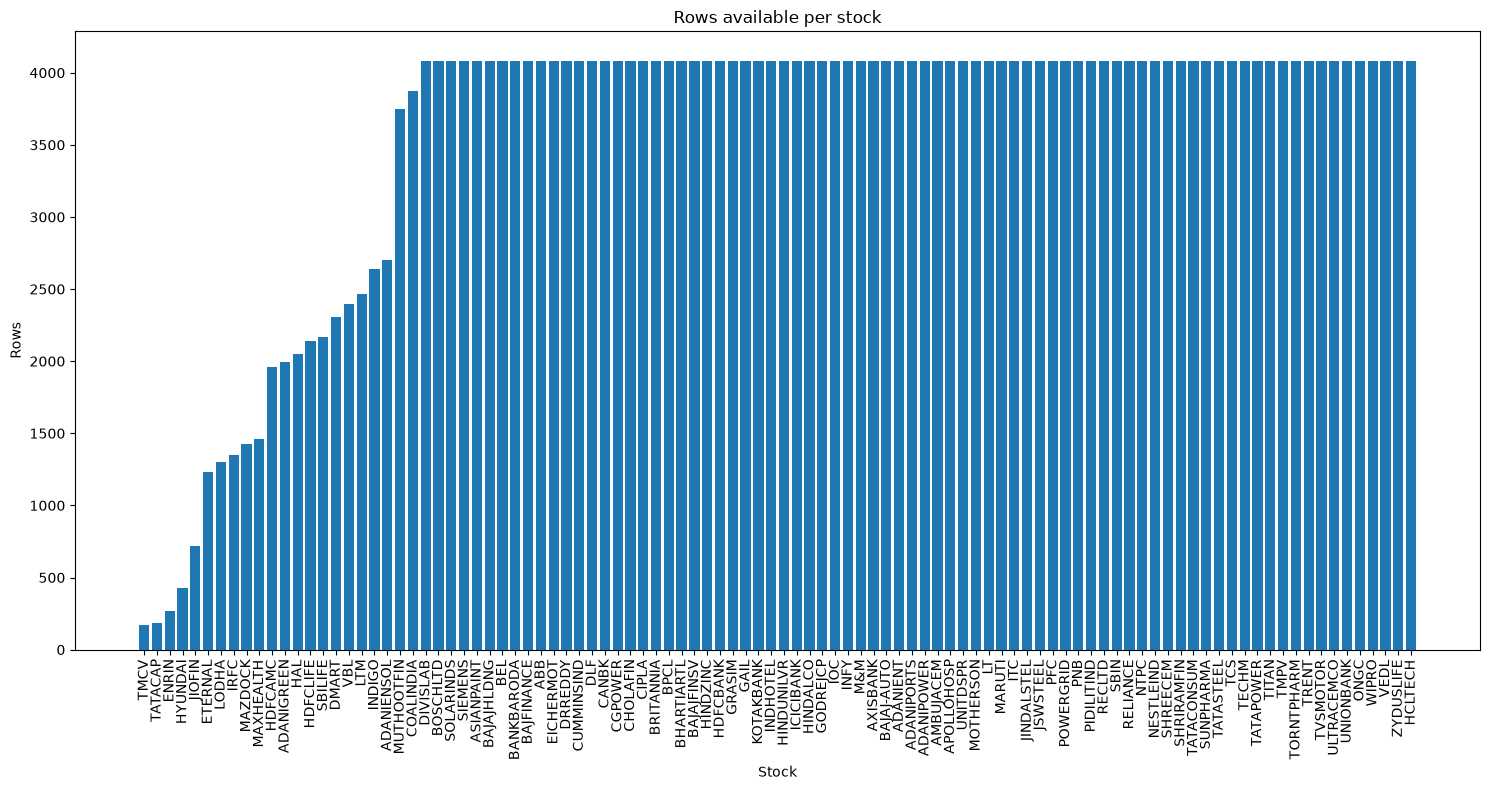

In [20]:
plt.figure(figsize=(15, 8))
plt.bar(coverage["symbol"], coverage["rows"])
plt.xticks(rotation=90)
plt.title("Rows available per stock")
plt.xlabel("Stock")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

### Latest date check

In [21]:
latest_stock_date = stocks["date"].max()
latest_index_date = indices["date"].max()

print("Latest stock date:", latest_stock_date)
print("Latest index date:", latest_index_date)

stale_stocks = stock_quality[stock_quality["end_date"] < latest_stock_date]
stale_indices = index_quality[index_quality["end_date"] < latest_index_date]

print("Stale stocks:", len(stale_stocks))
display(stale_stocks)

print("Stale indices:", len(stale_indices))
display(stale_indices)

Latest stock date: 2026-07-14 00:00:00
Latest index date: 2026-07-14 00:00:00
Stale stocks: 0


,asset_type,yf_ticker,symbol,rows,start_date,end_date,duplicate_dates,missing_open,missing_high,missing_low,missing_close,missing_adj_close,missing_volume,zero_or_negative_prices,negative_volume,zero_volume_days,large_move_gt_20pct,max_1d_gain_pct,max_1d_loss_pct,dividend_rows,split_rows


Stale indices: 0


,asset_type,yf_ticker,symbol,rows,start_date,end_date,duplicate_dates,missing_open,missing_high,missing_low,missing_close,missing_adj_close,missing_volume,zero_or_negative_prices,negative_volume,zero_volume_days,large_move_gt_20pct,max_1d_gain_pct,max_1d_loss_pct,dividend_rows,split_rows


### EDA for Returns of the stocks

In [22]:
stocks = stocks.sort_values(["yf_ticker", "date"]).copy()
stocks["return_1d"] = stocks.groupby("yf_ticker")["close"].pct_change()
stocks["return_20d"] = stocks.groupby("yf_ticker")["close"].pct_change(20)

display(stocks[["date", "yf_ticker", "close", "return_1d", "return_20d"]].head())

,date,yf_ticker,close,return_1d,return_20d
0,2010-01-04,ABB.NS,694.875061,NaN,NaN
1,2010-01-05,ABB.NS,693.104736,-0.002548,NaN
2,2010-01-06,ABB.NS,693.331665,0.000327,NaN
3,2010-01-07,ABB.NS,710.217834,0.024355,NaN
4,2010-01-08,ABB.NS,722.655518,0.017512,NaN


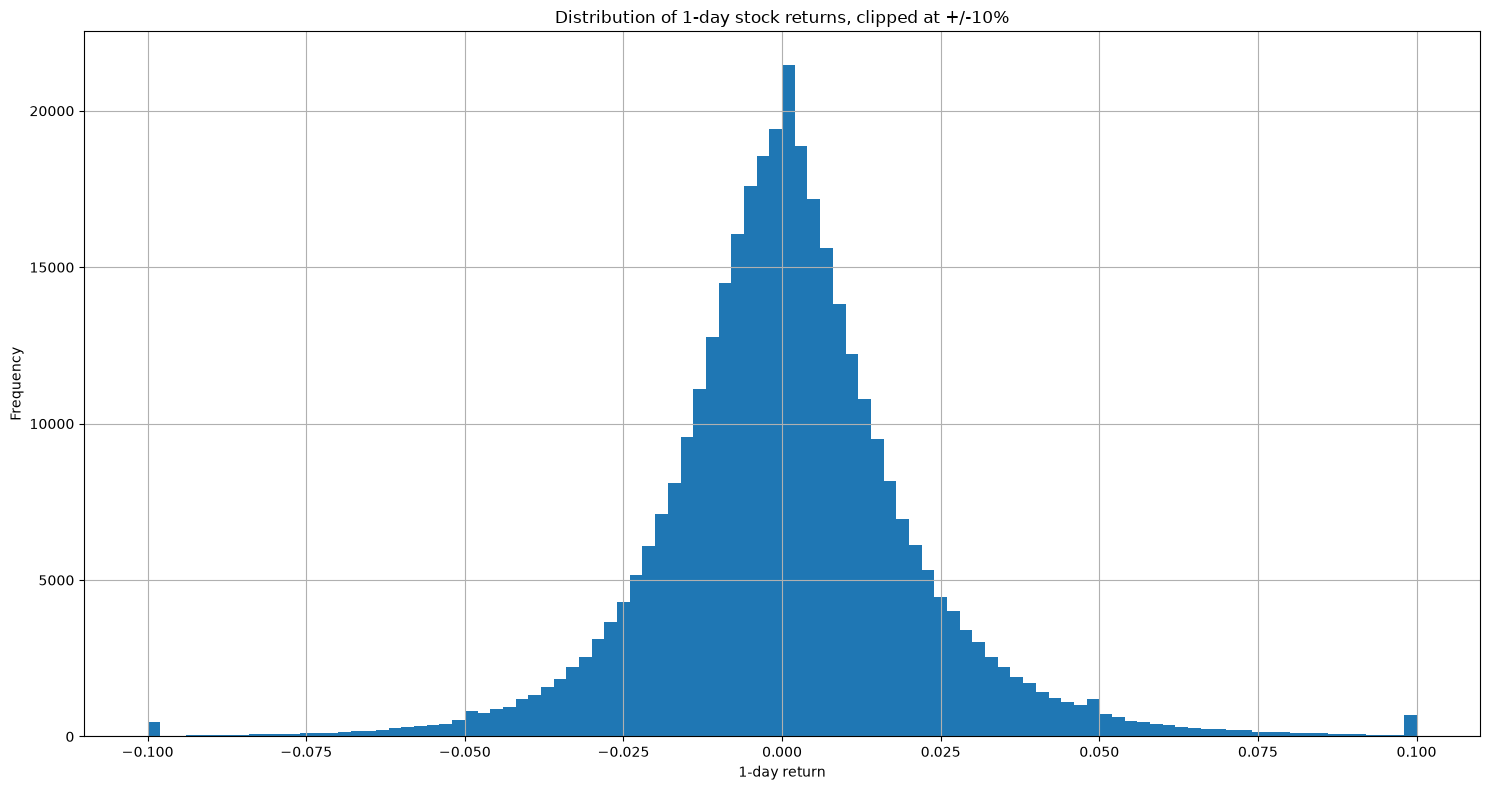

In [27]:
plt.figure(figsize=(15, 8))
stocks["return_1d"].dropna().clip(-0.10, 0.10).hist(bins=100)
plt.title("Distribution of 1-day stock returns, clipped at +/-10%")
plt.xlabel("1-day return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Volatility EDA

In [30]:
volatility_summary = (
    stocks
    .groupby("yf_ticker")["return_1d"]
    .std()
    .mul(100)
    .reset_index(name="daily_volatility_pct")
    .sort_values("daily_volatility_pct", ascending=False)
)

display(volatility_summary.head())
display(volatility_summary.tail())

,yf_ticker,daily_volatility_pct
3,ADANIGREEN.NS,3.436118
1,ADANIENSOL.NS,3.254898
2,ADANIENT.NS,3.185803
62,MAZDOCK.NS,3.175934
5,ADANIPOWER.NS,3.159170


,yf_ticker,daily_volatility_pct
85,TCS.NS,1.563433
51,ITC.NS,1.526537
71,POWERGRID.NS,1.524243
42,HINDUNILVR.NS,1.459983
39,HDFCBANK.NS,1.447290


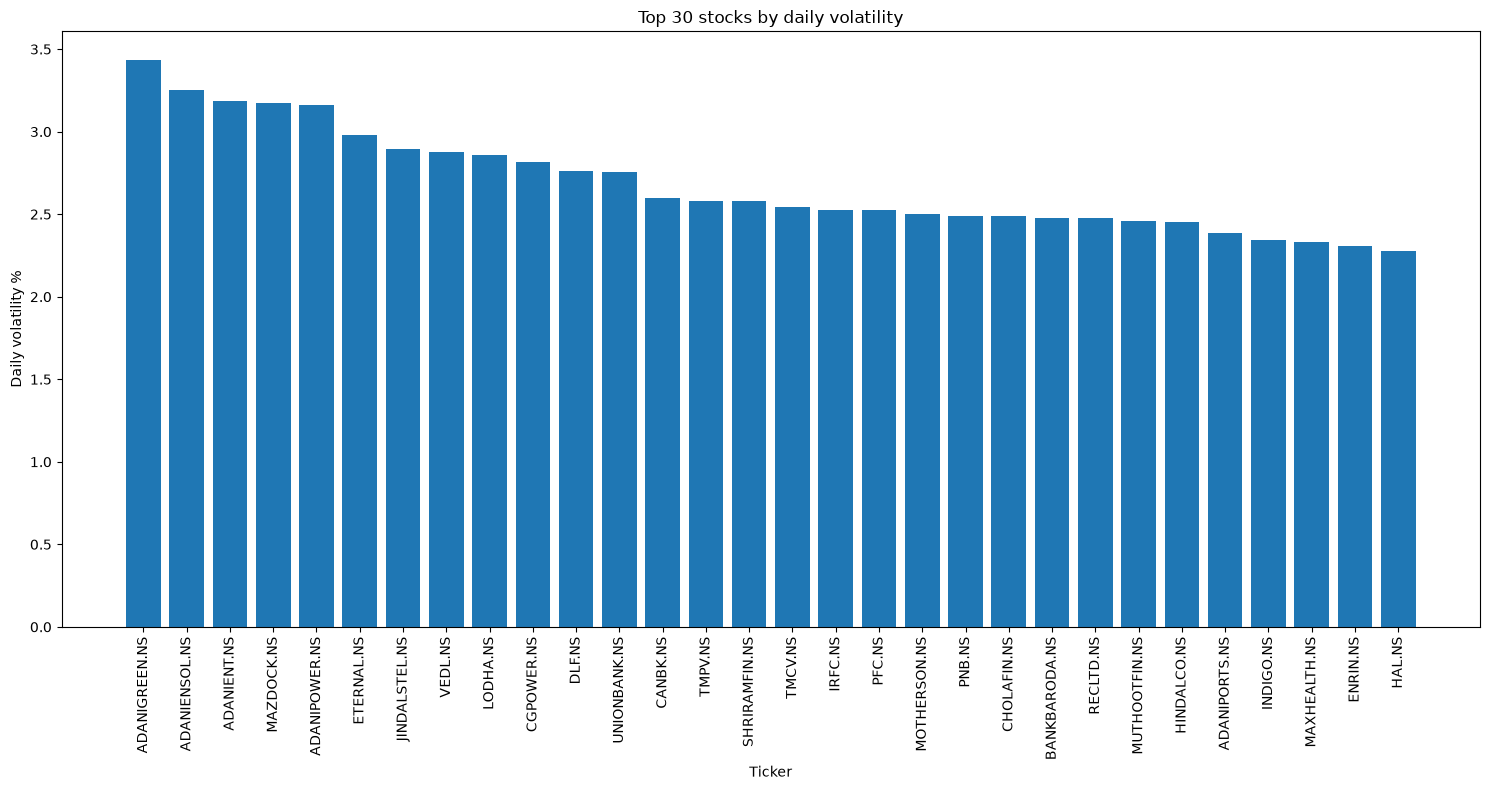

In [32]:
top_vol = volatility_summary.head(30)

plt.figure(figsize=(15, 8))
plt.bar(top_vol["yf_ticker"], top_vol["daily_volatility_pct"])
plt.xticks(rotation=90)
plt.title("Top 30 stocks by daily volatility")
plt.xlabel("Ticker")
plt.ylabel("Daily volatility %")
plt.tight_layout()
plt.show()

### Volume EDA

In [35]:
if "volume" in stocks.columns:
    volume_summary = (
        stocks
        .groupby("yf_ticker")["volume"]
        .median()
        .reset_index(name="median_daily_volume")
        .sort_values("median_daily_volume", ascending=False)
    )

    display(volume_summary.head(10))
    display(volume_summary.tail(10))

,yf_ticker,median_daily_volume
84,TATASTEEL.NS,54643641.5
32,ETERNAL.NS,43008441.5
5,ADANIPOWER.NS,23989926.5
20,CANBK.NS,19435028.5
75,SBIN.NS,17455113.0
50,IRFC.NS,16007019.5
45,ICICIBANK.NS,15927157.5
63,MOTHERSON.NS,15449336.5
53,JIOFIN.NS,15183090.0
70,PNB.NS,14421090.0


,yf_ticker,median_daily_volume
7,APOLLOHOSP.NS,295669.0
19,BRITANNIA.NS,261329.5
93,ULTRACEMCO.NS,251634.0
90,TORNTPHARM.NS,244370.0
58,LTM.NS,232055.0
0,ABB.NS,110526.0
12,BAJAJHLDNG.NS,29752.0
79,SOLARINDS.NS,26975.0
76,SHREECEM.NS,19539.0
17,BOSCHLTD.NS,15876.0


### Index coverage EDA

In [36]:
display(index_quality.sort_values("rows"))

indices = indices.sort_values(["yf_ticker", "date"]).copy()
indices["return_1d"] = indices.groupby("yf_ticker")["close"].pct_change()

index_return_summary = (
    indices
    .groupby("yf_ticker")["return_1d"]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
)

index_return_summary["daily_volatility_pct"] = index_return_summary["std"] * 100

display(index_return_summary.sort_values("daily_volatility_pct", ascending=False))

,asset_type,yf_ticker,symbol,rows,start_date,end_date,duplicate_dates,missing_open,missing_high,missing_low,missing_close,missing_adj_close,missing_volume,zero_or_negative_prices,negative_volume,zero_volume_days,large_move_gt_20pct,max_1d_gain_pct,max_1d_loss_pct,dividend_rows,split_rows
2,index,^CNXCMDT,Nifty Commodities,3641,2011-09-07,2026-07-14,0,0,0,0,0,0,0,0,0,2117,0,7.602370,-12.248414,0,0
6,index,^CNXMEDIA,Nifty Media,3663,2011-08-04,2026-07-14,0,0,0,0,0,0,0,0,0,2139,0,14.397564,-16.374076,0,0
7,index,^CNXMETAL,Nifty Metal,3680,2011-07-12,2026-07-14,0,0,0,0,0,0,0,0,0,986,0,9.842209,-11.601738,0,0
1,index,^CNXAUTO,Nifty Auto,3680,2011-07-12,2026-07-14,0,0,0,0,0,0,0,0,0,986,0,10.406259,-13.847843,0,0
4,index,^CNXFMCG,Nifty FMCG,3791,2011-01-31,2026-07-14,0,0,0,0,0,0,0,0,0,40,0,8.318530,-10.595370,0,0
3,index,^CNXENERGY,Nifty Energy,3792,2011-01-31,2026-07-14,0,0,0,0,0,0,0,0,0,40,0,8.634409,-12.465240,0,0
10,index,^CNXPSE,Nifty PSE,3792,2011-01-31,2026-07-14,0,0,0,0,0,0,0,0,0,40,0,8.655043,-16.384866,0,0
8,index,^CNXMNC,Nifty MNC,3792,2011-01-31,2026-07-14,0,0,0,0,0,0,0,0,0,40,0,7.838163,-12.047444,0,0
11,index,^CNXPSUBANK,Nifty PSU Bank,3792,2011-01-31,2026-07-14,0,0,0,0,0,0,0,0,0,40,1,29.626454,-15.137112,0,0
9,index,^CNXPHARMA,Nifty Pharma,3805,2011-01-31,2026-07-14,0,0,0,0,0,0,0,0,0,33,0,10.367991,-8.926873,0,0


,yf_ticker,count,mean,std,min,max,daily_volatility_pct
13,^INDIAVIX,4059,0.001298,0.054558,-0.339407,0.656250,5.455792
11,^CNXPSUBANK,3791,0.000391,0.020510,-0.151371,0.296265,2.050962
12,^CNXREALTY,3926,0.000383,0.020030,-0.116044,0.086569,2.002958
7,^CNXMETAL,3679,0.000482,0.017556,-0.116017,0.098422,1.755614
6,^CNXMEDIA,3662,0.000168,0.016476,-0.163741,0.143976,1.647634
14,^NSEBANK,4073,0.000555,0.014343,-0.167340,0.105117,1.434313
5,^CNXIT,4073,0.000481,0.013476,-0.117418,0.093321,1.347595
1,^CNXAUTO,3679,0.000625,0.013438,-0.138478,0.104063,1.343818
10,^CNXPSE,3791,0.000356,0.013153,-0.163849,0.086550,1.315286
3,^CNXENERGY,3791,0.000481,0.013082,-0.124652,0.086344,1.308244


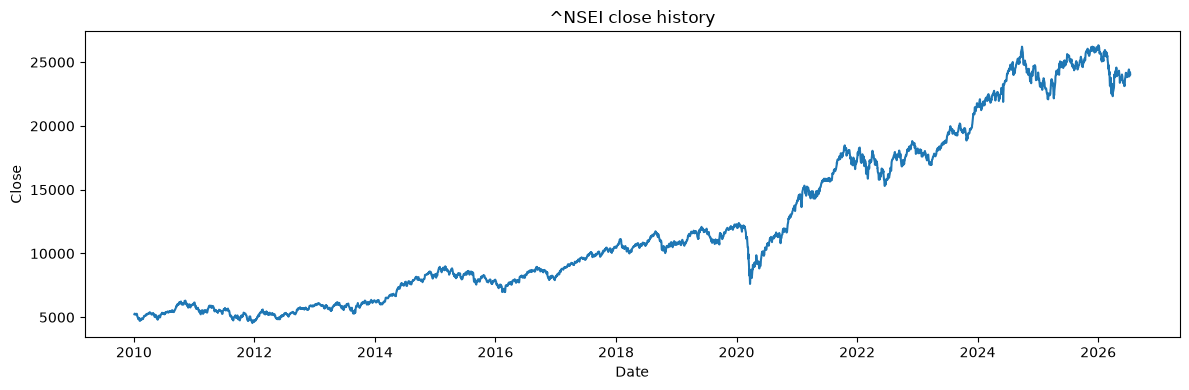

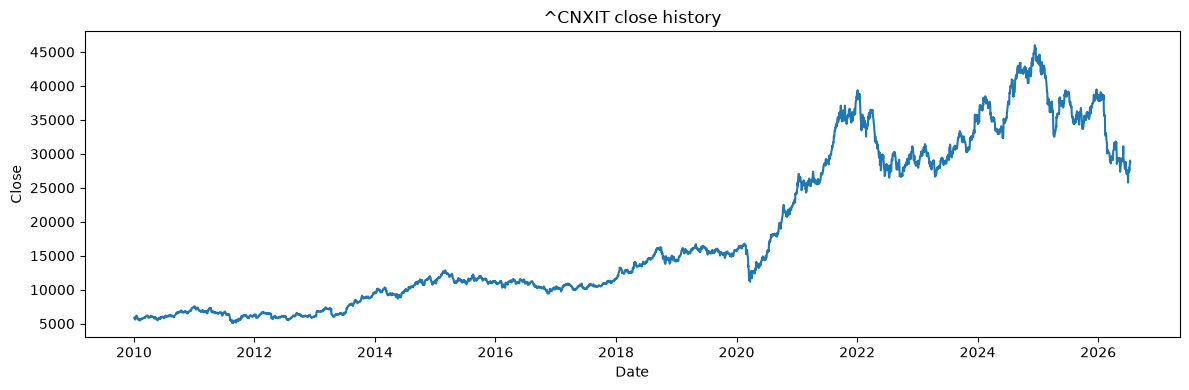

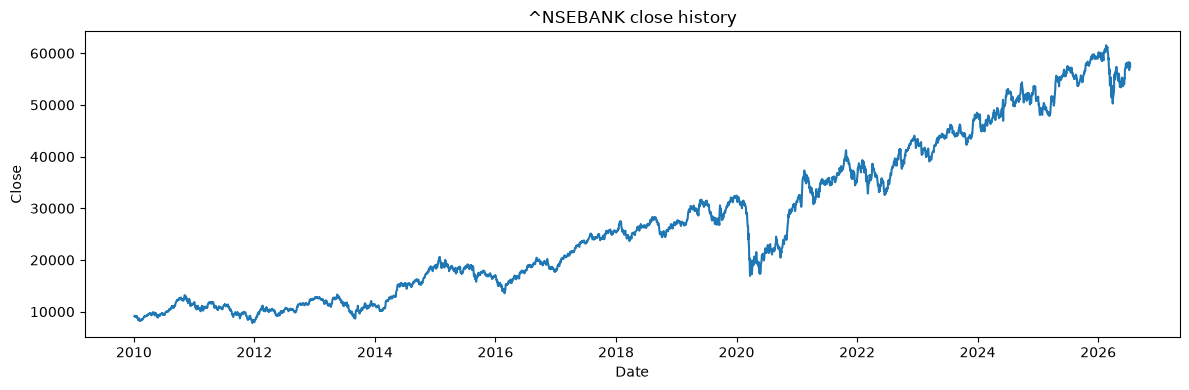

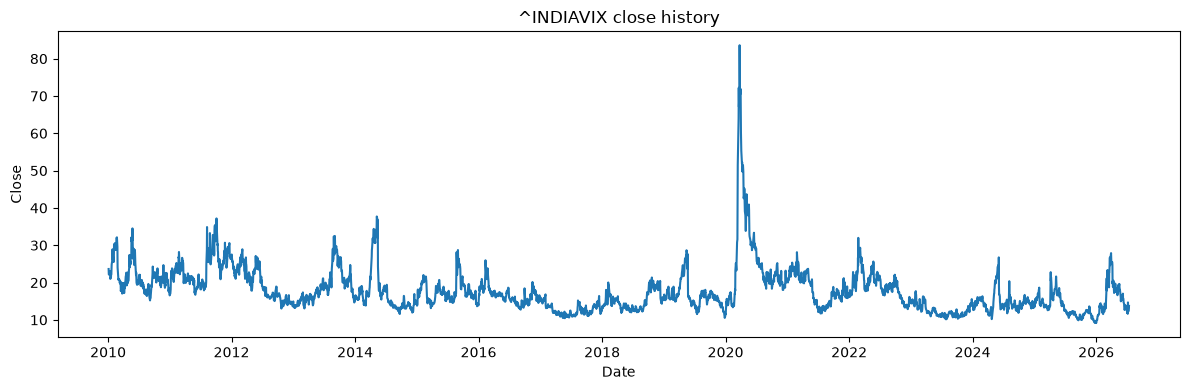

In [38]:
major_indices = ["^NSEI", "^CNXIT", "^NSEBANK", "^INDIAVIX"]

for ticker in major_indices:
    subset = indices[indices["yf_ticker"] == ticker].copy()

    if subset.empty:
        continue

    plt.figure(figsize=(12, 4))
    plt.plot(subset["date"], subset["close"])
    plt.title(f"{ticker} close history")
    plt.xlabel("Date")
    plt.ylabel("Close")
    plt.tight_layout()
    plt.show()

### Final acceptance summary

In [39]:
stock_acceptance = stock_quality.copy()

stock_acceptance["status"] = "OK"

stock_acceptance.loc[
    stock_acceptance["rows"] < 1500,
    "status"
] = "FLAG_SHORT_HISTORY"

stock_acceptance.loc[
    stock_acceptance["missing_close"] > 0,
    "status"
] = "FLAG_MISSING_CLOSE"

stock_acceptance.loc[
    stock_acceptance["zero_or_negative_prices"] > 0,
    "status"
] = "FLAG_BAD_PRICE"

stock_acceptance.loc[
    stock_acceptance["duplicate_dates"] > 0,
    "status"
] = "FLAG_DUPLICATES"

display(stock_acceptance["status"].value_counts())
display(stock_acceptance[stock_acceptance["status"] != "OK"])

status
OK                    90
FLAG_SHORT_HISTORY    10
Name: count, dtype: int64

,asset_type,yf_ticker,symbol,rows,start_date,end_date,duplicate_dates,missing_open,missing_high,missing_low,missing_close,missing_adj_close,missing_volume,zero_or_negative_prices,negative_volume,zero_volume_days,large_move_gt_20pct,max_1d_gain_pct,max_1d_loss_pct,dividend_rows,split_rows,status
31,stock,ENRIN.NS,ENRIN,267,2025-06-19,2026-07-14,0,0,0,0,0,0,0,0,0,4,0,9.359889,-7.550359,1,0,FLAG_SHORT_HISTORY
32,stock,ETERNAL.NS,ETERNAL,1232,2021-07-23,2026-07-14,0,0,0,0,0,0,0,0,0,8,0,19.978402,-19.621648,0,0,FLAG_SHORT_HISTORY
44,stock,HYUNDAI.NS,HYUNDAI,430,2024-10-22,2026-07-14,0,0,0,0,0,0,0,0,0,5,0,8.153700,-5.658826,1,0,FLAG_SHORT_HISTORY
50,stock,IRFC.NS,IRFC,1350,2021-01-29,2026-07-14,0,0,0,0,0,0,0,0,0,6,1,25.088187,-13.500326,11,0,FLAG_SHORT_HISTORY
53,stock,JIOFIN.NS,JIOFIN,717,2023-08-21,2026-07-14,0,0,0,0,0,0,0,0,0,6,0,13.908590,-9.299432,1,0,FLAG_SHORT_HISTORY
56,stock,LODHA.NS,LODHA,1298,2021-04-19,2026-07-14,0,0,0,0,0,0,0,0,0,6,0,18.064513,-11.594750,3,2,FLAG_SHORT_HISTORY
61,stock,MAXHEALTH.NS,MAXHEALTH,1461,2020-08-21,2026-07-14,0,0,0,0,0,0,0,0,0,5,0,17.770821,-8.391780,4,0,FLAG_SHORT_HISTORY
62,stock,MAZDOCK.NS,MAZDOCK,1426,2020-10-12,2026-07-14,0,0,0,0,0,0,0,0,0,6,0,19.755243,-17.746196,13,1,FLAG_SHORT_HISTORY
81,stock,TATACAP.NS,TATACAP,188,2025-10-13,2026-07-14,0,0,0,0,0,0,0,0,0,4,0,6.180337,-4.761905,0,0,FLAG_SHORT_HISTORY
88,stock,TMCV.NS,TMCV,168,2025-11-12,2026-07-14,0,0,0,0,0,0,0,0,0,4,0,9.594748,-7.670724,1,0,FLAG_SHORT_HISTORY


In [40]:
STOCK_ACCEPTANCE_PATH = QUALITY_REPORT_DIR / "stock_acceptance_report.csv"

stock_acceptance.to_csv(STOCK_ACCEPTANCE_PATH, index=False)

print("Saved:", STOCK_ACCEPTANCE_PATH)

Saved: E:\Projects\marketguard-india\data\interim\quality_reports\stock_acceptance_report.csv
